# Módulo 2 · Del *machine learning* al *deep learning*
## Notebook 2 — **LSTM** aplicado a series financieras

> **Dónde estamos.** En el notebook anterior, **XGBoost** reformuló la predicción
> como regresión sobre una **tabla de features que diseñamos** (lags, medias
> móviles, volatilidad…). El modelo no sabía nada de tiempo; se lo dabas hecho.
>
> El **LSTM** cambia otra vez el paradigma: le pasamos la **secuencia cruda** y la
> red **aprende ella sola** qué representación temporal le conviene.

---
## 0. Preparación del entorno
Ejecuta esta celda primero. En Colab, TensorFlow ya viene instalado.

In [ ]:
# @title Setup (ejecutar primero) { display-mode: "form" }
import sys, subprocess, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # silencia los logs de TF
def _pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
_pip(["yfinance", "scikit-learn", "statsmodels"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 4)
print("Entorno listo ✅  TensorFlow", tf.__version__)

Entorno listo ✅  TensorFlow 2.20.0


---
## 1. Los datos
Mismos datos que en el notebook de XGBoost: precios diarios del S&P 500 (^GSPC)

In [ ]:
TICKER = "^GSPC"
START, END = "2015-01-01", "2024-12-31"

def load_prices():
    try:
        import yfinance as yf
        data = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)
        if data is None or len(data) == 0:
            raise RuntimeError("descarga vacía")
        s = data["Close"]
        s = s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s
        print(f"Datos reales descargados: {len(s)} sesiones de {TICKER}")
        return s.rename("Close")
    except Exception as e:
        print(f"⚠️  Sin datos reales ({e}). Uso serie SINTÉTICA con hechos estilizados realistas.")
        rng = np.random.default_rng(RANDOM_STATE)
        n = 2400
        base = np.log(0.009)
        logvol = np.full(n, base)
        for t in range(1, n):
            logvol[t] = 0.94 * logvol[t-1] + 0.06 * base + 0.15 * rng.standard_normal()
        sigma = np.exp(logvol)
        z = rng.standard_t(df=10, size=n) / np.sqrt(10 / 8.0)
        ret = 0.0007 + sigma * z
        jumps = rng.random(n) < 0.012
        ret[jumps] -= np.abs(rng.normal(0.0, 0.03, jumps.sum()))
        ret[850:910] -= 0.012
        price = 2000 * np.exp(np.cumsum(ret))
        idx = pd.bdate_range("2015-01-02", periods=n)
        return pd.Series(price, index=idx, name="Close")

prices = load_prices()

# Trabajamos en rendimientos (la lección del notebook anterior). Tabla base alineada:
df = pd.DataFrame({"price": prices})
df["ret"] = df["price"].pct_change()
df = df.dropna()
df.tail()

Datos reales descargados: 2515 sesiones de ^GSPC


,price,ret
Date,,
2024-12-23,5974.069824,0.007287
2024-12-24,6040.040039,0.011043
2024-12-26,6037.589844,-0.000406
2024-12-27,5970.839844,-0.011056
2024-12-30,5906.939941,-0.010702


---
## 2 · EDA orientado al LSTM
Dos preguntas que condicionan cómo montaremos la red:

1. **¿Cuánta "memoria" hay en la serie?** Nos dice cuántos días atrás debe mirar
   la red (la *ventana* o `lookback`). Lo vemos con la ACF y la PACF.
2. **¿En qué escala viven los datos?** Las redes neuronales son **sensibles a la
   escala** (los árboles no), así que tendremos que normalizar.

La primera celda es para observar; en la segunda completas los `# TODO`.

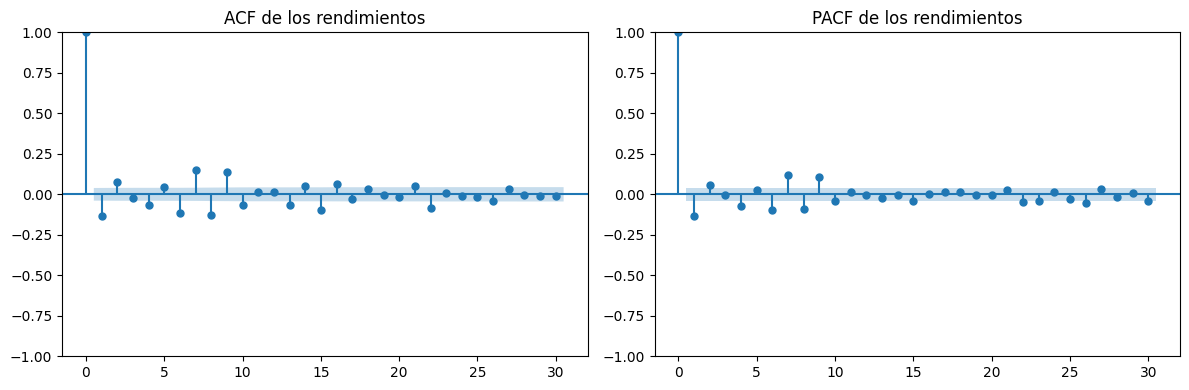

Si casi todas las barras caen dentro de la banda azul -> memoria LINEAL ≈ 0.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ret = df["ret"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ret, lags=30, ax=ax[0]);  ax[0].set_title("ACF de los rendimientos")
plot_pacf(ret, lags=30, ax=ax[1], method="ywm"); ax[1].set_title("PACF de los rendimientos")
plt.tight_layout(); plt.show()
print("Si casi todas las barras caen dentro de la banda azul -> memoria LINEAL ≈ 0.")

In [ ]:
# La escala: precio vs rendimiento viven en mundos distintos.
# TODO 1: rango (min, max) del PRECIO y del RENDIMIENTO
price_range = (df["price"].min(), df["price"].max())
ret_range   = (df["ret"].min(),   df["ret"].max())
print("Rango precio:     ", tuple(round(float(v), 4) for v in price_range))
print("Rango rendimiento:", tuple(round(float(v), 4) for v in ret_range))

# Una red necesita inputs normalizados. Veamos qué hace estandarizar (media 0, desv 1).
# TODO 2: estandariza los rendimientos y comprueba media≈0, desv≈1
r_demo = StandardScaler().fit_transform(df[["ret"]])         # <-- completa  (pista: StandardScaler().fit_transform(df[["ret"]]))
print(f"Tras estandarizar -> media={r_demo.mean():.3f}, desv={r_demo.std():.3f}")

Rango precio:      (1829.08, 6090.27)
Rango rendimiento: (-0.1198, 0.0938)
Tras estandarizar -> media=0.000, desv=1.000


---
## 3 · El cambio de paradigma: la red aprende las características de los datos

En XGBoost, definiamos la serie en columnas (`ret_lag1`, `roll_std10`…).
En un LSTM le das directamente una **ventana de la secuencia cruda** y la red
aprende qué hacer con ella.

**¿Cómo "recuerda" un LSTM?** Procesa la secuencia paso a paso manteniendo un
**estado** interno que se actualiza en cada instante:

$$h_t = f(h_{t-1},\, x_t)$$

La gracia del LSTM frente a una RNN simple son sus **puertas** (*gates*): unas
mini-redes que deciden, en cada paso, **qué olvidar**, **qué incorporar** de la
entrada nueva y **qué sacar**. Eso le permite mantener información relevante
durante muchos pasos sin que el gradiente se desvanezca.

**Consecuencias prácticas:**
- La entrada ya **no es una tabla 2D**, sino un tensor **3D**: `(muestras, timesteps, features)` (§4).
- Hay que **escalar** los datos.
- A diferencia de un árbol, el LSTM **sí puede extrapolar**.
- A cambio: necesita **más datos**, **más cómputo**, tiene **más hiperparámetros**
  y es **menos interpretable**.

> **Pregunta** "Que la red aprenda las features sola" suena a que nos
> ahorramos trabajo. ¿Qué trabajo *nuevo* aparece a cambio?


---
## 4. De serie a secuencias (ventana deslizante)

LSTM aprende los patrones en secuencias de datos, si le dieramos toda la serie con más de 2 mil datos, solo tendría una secucencia larguísima de la que aprender. La partimos en secuencias más pequeñas con solape para no perder contexto.

Cada muestra son `LOOKBACK` valores pasados
(la entrada `X`) y el valor siguiente (el *target* `y`).

Completa el `# TODO` del corte de ventana.

In [ ]:
LOOKBACK = 20   # nº de días que la red "ve" para predecir el siguiente (un mes bursátil)

def make_windows(series_1d, lookback):
    X, y = [], []
    for i in range(lookback, len(series_1d)):
        # TODO: la entrada es la ventana de los 'lookback' valores ANTERIORES a i;
        #       el target es el valor en i.
        X.append(series_1d[i-lookback:i])   # ventana de 'lookback' días anteriores
        y.append(series_1d[i])              # el día siguiente (target)   # <-- completa  (pista: series_1d[i])
    X = np.array(X)[..., None]   # añade la dimensión de features -> 3D (muestras, timesteps, 1)
    return X, np.array(y)

# prueba rápida de formas
_X, _y = make_windows(df["ret"].values.astype("float32"), LOOKBACK)
print("X:", _X.shape, " (muestras, timesteps, features)   y:", _y.shape)

X: (2494, 20, 1)  (muestras, timesteps, features)   y: (2494,)


---
## 5. Escalado **sin leakeage**
Las redes necesitan inputs normalizados. Pero el `StandardScaler` aprende una
media y una desviación: si las calcula con **todos** los datos, está mirando el
futuro (test) para normalizar el pasado → **fuga**. La regla, idéntica a la del
notebook anterior: **ajustar (`fit`) solo con train**, y luego transformar todo.

Orden correcto: partir en el tiempo → `fit` del scaler en train → transformar →
construir las ventanas.

Completa el `# TODO`.

In [ ]:
ret_arr = df["ret"].values.astype("float32")
split = int(len(ret_arr) * 0.8)          # corte temporal 80/20

scaler = StandardScaler()
# TODO: ajusta el scaler SOLO con la parte de train, NO con todo
scaler.fit(ret_arr[:split].reshape(-1, 1))                       # <-- completa (pista: ret_arr[:split].reshape(-1,1))
ret_scaled = scaler.transform(ret_arr.reshape(-1,1)).flatten()

# ventanas sobre la serie escalada, y split temporal de las ventanas
X_all, y_all = make_windows(ret_scaled, LOOKBACK)
wsplit = split - LOOKBACK                # el target de la ventana j cae en el día LOOKBACK+j
X_train, X_test = X_all[:wsplit], X_all[wsplit:]
y_train, y_test = y_all[:wsplit], y_all[wsplit:]
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1991, 20, 1) | Test: (503, 20, 1)


---
## 6. Baseline
Igual que antes: el rival a batir es el **paseo aleatorio** (rendimiento de mañana
= 0). Lo guardamos en escala de rendimiento para comparar.

In [ ]:
actual_ret_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
rmse_naive_ret = mean_squared_error(actual_ret_test, np.zeros_like(actual_ret_test)) ** 0.5
print(f"RMSE paseo aleatorio (ret): {rmse_naive_ret:.5f}")

RMSE paseo aleatorio (ret): 0.00817


---
## 7. Un LSTM que predice el **precio**
Vamos a entrenar un LSTM para predecir el
**precio** y dibujar predicción vs. real.

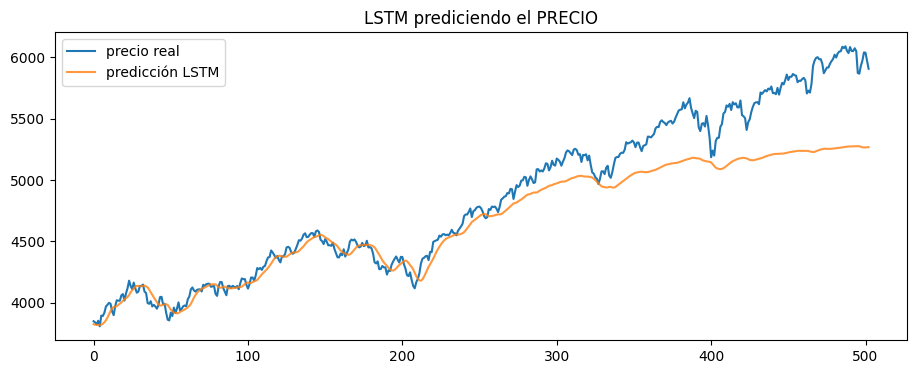

In [ ]:
# preparamos ventanas de PRECIO (escalado sin fuga, igual que antes)
price_arr = df["price"].values.astype("float32")
psplit = int(len(price_arr) * 0.8)
sc_price = StandardScaler().fit(price_arr[:psplit].reshape(-1,1))
price_scaled = sc_price.transform(price_arr.reshape(-1,1)).flatten()
Xp, yp = make_windows(price_scaled, LOOKBACK)
pw = psplit - LOOKBACK
Xp_tr, Xp_te, yp_tr, yp_te = Xp[:pw], Xp[pw:], yp[:pw], yp[pw:]

tf.random.set_seed(RANDOM_STATE)
trap = Sequential([Input((LOOKBACK,1)), LSTM(24), Dense(1)])
trap.compile(optimizer="adam", loss="mse")
trap.fit(Xp_tr, yp_tr, epochs=12, batch_size=32, verbose=0)

pred_price   = sc_price.inverse_transform(trap.predict(Xp_te, verbose=0)).flatten()
actual_price = sc_price.inverse_transform(yp_te.reshape(-1,1)).flatten()

plt.plot(actual_price, label="precio real")
plt.plot(pred_price, label="predicción LSTM", alpha=0.8)
plt.title("LSTM prediciendo el PRECIO"); plt.legend(); plt.show()

In [ ]:
# El test de la verdad: ¿la predicción de hoy se parece al precio de AYER?
prev_price = sc_price.inverse_transform(Xp_te[:, -1, :]).flatten()  # último valor de cada ventana
corr = np.corrcoef(pred_price, prev_price)[0, 1]
rmse_lstm  = mean_squared_error(actual_price, pred_price) ** 0.5
rmse_naive = mean_squared_error(actual_price, prev_price) ** 0.5
print(f"corr(predicción, precio de AYER) = {corr:.3f}")
print(f"RMSE LSTM: {rmse_lstm:.2f}   |   RMSE 'mañana = hoy' (naive): {rmse_naive:.2f}")

corr(predicción, precio de AYER) = 0.977
RMSE LSTM: 296.98   |   RMSE 'mañana = hoy' (naive): 39.45


> La correlación entre la predicción y el **precio de ayer** es casi 1, y el RMSE
> del LSTM no le gana (o pierde) al naive "mañana = hoy". El gráfico es bonito
> porque la red ha aprendido lo único fácil: **copiar el último valor** (el
> *pronóstico de persistencia*). Desplaza mentalmente la curva predicha un día a
> la derecha y verás que va **siempre un paso por detrás**.


---
## 8. LSTM sobre **rendimientos**
Volvemos a `X_train`/`y_train` (rendimientos escalados de la §5). Define una red
sencilla. Completa el `# TODO` con la arquitectura.

In [ ]:
tf.random.set_seed(RANDOM_STATE)
# TODO: una capa LSTM de 24 unidades + una capa de salida Dense(1)
model = Sequential([
    Input((LOOKBACK, 1)),
    LSTM(24),        # <-- capa recurrente: 24 unidades
    Dense(1),        # <-- capa de salida: 1 valor (el rendimiento de mañana)
])
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521 (9.85 KB)

 Trainable params: 2,521 (9.85 KB)

 Non-trainable params: 0 (0.00 B)

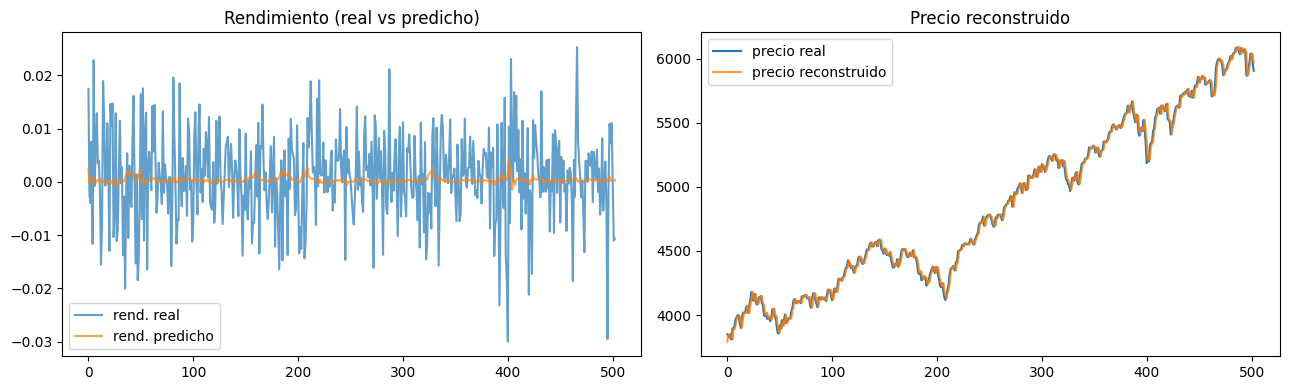

In [ ]:
history = model.fit(X_train, y_train, epochs=15, batch_size=32,
                    validation_split=0.1, verbose=0)

pred_ret    = scaler.inverse_transform(model.predict(X_test, verbose=0)).flatten()
actual_ret  = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# reconstruir el precio: precio_t = precio_(t-1) * (1 + ret_t)
prev_price_r = df["price"].iloc[split-1:-1].values
pred_price_r = prev_price_r * (1 + pred_ret)
actual_price_r = df["price"].iloc[split:].values

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(actual_ret, label="rend. real", alpha=.7); ax[0].plot(pred_ret, label="rend. predicho", alpha=.7)
ax[0].set_title("Rendimiento (real vs predicho)"); ax[0].legend()
ax[1].plot(actual_price_r, label="precio real"); ax[1].plot(pred_price_r, label="precio reconstruido", alpha=.8)
ax[1].set_title("Precio reconstruido"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## 9. Evaluación
La métrica que importa: **precisión direccional** (¿acertamos el signo?). 50% es
una moneda al aire. Completa el `# TODO`.

In [ ]:
def directional_accuracy(y_true_ret, y_pred_ret):
    return np.mean(np.sign(y_pred_ret) == np.sign(y_true_ret))  # <-- completa (pista: np.mean(np.sign(...) == np.sign(...)))

rmse = mean_squared_error(actual_ret, pred_ret) ** 0.5
da   = directional_accuracy(actual_ret, pred_ret)
print(f"RMSE rendimiento:      {rmse:.5f}   (paseo aleatorio: {rmse_naive_ret:.5f})")
print(f"Precisión direccional: {da:.1%}   (azar = 50%)")

RMSE rendimiento:      0.00811   (paseo aleatorio: 0.00817)
Precisión direccional: 54.5%   (azar = 50%)


---
## 10. Curvas de entrenamiento y **sobreajuste**
Un modelo con muchos parámetros puede **memorizar el ruido** del entrenamiento. La
forma de verlo: la *loss* de train baja mientras la de validación **sube**.
Entrenamos a propósito una red más grande, muchas épocas y sin frenos.

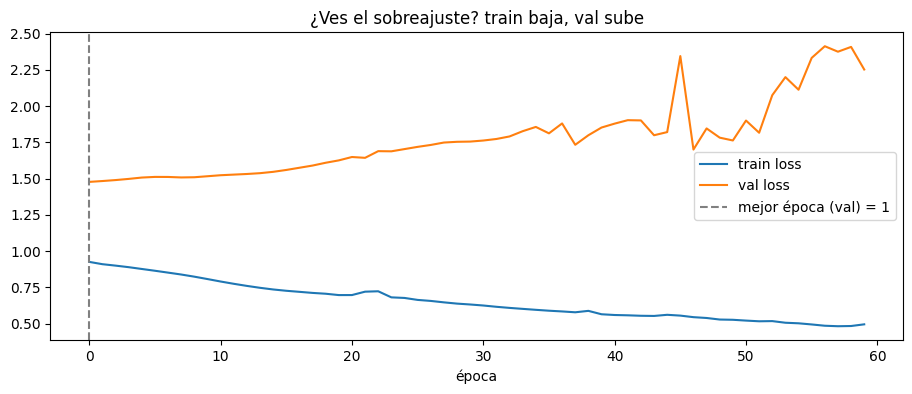

train: 0.925 -> 0.494
val:   1.477 -> mínimo 1.477 (ep 1) -> 2.252


In [ ]:
tf.random.set_seed(0)
big = Sequential([Input((LOOKBACK,1)), LSTM(64), Dense(1)])
big.compile(optimizer="adam", loss="mse")
h = big.fit(X_train, y_train, epochs=60, batch_size=16, validation_split=0.15, verbose=0)

best = int(np.argmin(h.history["val_loss"]))
plt.plot(h.history["loss"], label="train loss")
plt.plot(h.history["val_loss"], label="val loss")
plt.axvline(best, ls="--", c="grey", label=f"mejor época (val) = {best+1}")
plt.title("¿Ves el sobreajuste? train baja, val sube"); plt.xlabel("época"); plt.legend(); plt.show()
print(f"train: {h.history['loss'][0]:.3f} -> {h.history['loss'][-1]:.3f}")
print(f"val:   {h.history['val_loss'][0]:.3f} -> mínimo {min(h.history['val_loss']):.3f} (ep {best+1}) -> {h.history['val_loss'][-1]:.3f}")

**Ejercicio 1**

> Escribe al menos **tres** formas de reducir este
> sobreajuste, una por cada frente:
> - el **modelo** (¿qué cambiarías en la arquitectura?),
> - el **entrenamiento** (¿cuándo parar?, ¿qué añadir?),
> - los **datos** (¿qué les falta?).

- Reducir la capacidad de la red: bajar de 64 a 24 unidades en el LSTM, o añadir una capa Dropout después del LSTM que desactiva neuronas aleatoriamente durante el entrenamiento.

- Usar EarlyStopping, que ya está importado en el setup. Para el entrenamiento cuando la val_loss lleva N épocas sin mejorar y restaura los mejores pesos.

- Más datos y más variados. Con solo rendimientos diarios de un índice la red tiene muy poco de donde aprender. Añadir más historia (más años), más activos, o features adicionales como volumen, VIX o datos macroeconómicos daría más señal real y reduciría la proporción de ruido que el modelo intenta memorizar.

**Ejercicio 2**

> Con estos datos —precios/rendimientos diarios de un
> índice— ¿crees de verdad que se puede predecir la dirección del mercado?
> ¿Hay alguna teoría económica que respalde tu respuesta?
> Investiga al respecto

Por lo que hemos buscado, hay una teoría económica que lo respalda directamente: la Hipótesis de Mercado Eficiente (EMH) de Eugene Fama (1970).

Dice que el precio actual ya incorpora toda la información histórica de precios. Si fuera posible predecir la dirección mirando solo el pasado, los inversores lo explotarían hasta que la oportunidad desapareciera.

Dicho esto, la EMH tiene matices importantes:

- No dice que sea imposible siempre, sino que las oportunidades son efímeras y desaparecen cuando se descubren.
- La volatilidad sí es predecible (lo viste: los rendimientos² sí se autocorrelacionan). Hay estrategias rentables basadas en predecir el tamaño del movimiento, no su dirección.
- Con datos alternativos (noticias, sentiment, flujos de capital) sí hay evidencia de señal, aunque débil y costosa de explotar.
- Los modelos de ML tienen más valor en carteras de muchos activos (encontrar cuál sube relative a los demás) que en predecir un solo índice.
